In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
from shapely.geometry import Polygon, Point

import geopandas as gpd

# from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [3]:
#Select one report 
# all_reports = pd.read_csv(DATA_OUT_LLMS+'labelled_reports_response_llm_levels_haz_types_subtypes_impacts_geocoding.csv')
file_path = DATA_IN_JSONS +'all_ifrc_reports_info_unnested_with_text.json'#'nathaz_ifrc_reports_info_processed.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    ifrc_reports_processed = json.load(json_file)
all_reports = pd.DataFrame(ifrc_reports_processed)
all_reports = all_reports.rename({"location" : "country"}, axis=1)
# all_reports = all_reports.rename({"disasterTypeReclassified" : "hazardType"}, axis=1)

# Open external polygon and convert to same format 

In [53]:
gpd_files = open_admin_gpd(ADMIN_PATH, "geoBoundaries")

In [54]:
gpd_files["ADM_0"].head(2)

,id,iso3_code,shapeType,ADMIN_0,geometry
0,None,AFG,ADM0,Afghanistan,"POLYGON ((64.40511 29.54869, 64.40515 29.54857..."
1,None,GBR,ADM0,United Kingdom,"MULTIPOLYGON (((33.013 34.64377, 33.01273 34.6..."


In [55]:
gpd_files["ADM_1"].head(2)

,id,ADMIN_1,shapeID,iso3_code,shapeType,geometry,ADMIN_0
0,None,Kandahar,12653393B40111500734429,AFG,ADM1,"POLYGON ((64.50647 29.56715, 64.50634 29.56723...",Afghanistan
1,None,Zabul,12653393B56617740339660,AFG,ADM1,"POLYGON ((67.60667 31.44379, 67.60883 31.44908...",Afghanistan


In [56]:
gpd_files["ADM_2"].head(2)

,id,ADMIN_2,shapeID,iso3_code,shapeType,ADMIN_0_x,ADMIN_1,geometry,ADMIN_0_y
0,None,Deh Bala,17698898B67359070524975,AFG,ADM2,Afghanistan,Nangarhar,"MULTIPOLYGON (((70.51145 33.9492, 70.49436 33....",Afghanistan
1,None,Gulran,17698898B98443198567384,AFG,ADM2,Afghanistan,Herat,"MULTIPOLYGON (((62.00761 35.44595, 62.00906 35...",Afghanistan


In [44]:
cleaned_geometry = gpd_files["ADM_0"].iloc[0]["geometry"].buffer(0)

In [45]:
cleaned_geometry

In [101]:
gpd_files["ADM_2"]["shapeType"].value_counts()

shapeType
ADM2    49015
Name: count, dtype: int64

In [80]:
# Add an empty column
gpd_files["ADM_2"]["ADMIN_1"] = np.NaN

In [ ]:
# For ADMIN2 boundaries, try to the retrive the admin1 level 
for row_index, row_data in df_geo.iterrows():
    geom = row_data['geometry']
    # gpd_files_admin1_subset = gpd_files["ADM_1"].loc[qpd_files["ADM_1"]["iso3_code"]==row_data["iso3_code"]]
    adm1_match = get_polygon_for_geometry(geom, row_data["ADMIN_0"], gpd_files, level=1)
    df_geo.loc[row_index]["ADMIN_1"] = adm1_match["ADMIN_1"]

In [18]:
from pandarallel import pandarallel
pandarallel.initialize(nb_workers=8, progress_bar=True)

func = partial(match_admin1_for_row, gpd_files=gpd_files)
gpd_files["ADM_2"]["ADMIN_1"] = gpd_files["ADM_2"].parallel_apply(func, axis=1)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

https://nalepae.github.io/pandarallel/troubleshooting/


In [20]:
output_path = ADMIN_PATH + "geoBoundaries/geoBoundariesCGAZ_ADM2_corrected.gpkg"

# Save to GeoPackage
gpd_files["ADM_2"].to_file(output_path, layer="ADM_2", driver="GPKG")

# Convert location to polygons

In [21]:
#Post process files 
# df_labelled = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_labelled_reports_impacts_all.csv', encoding='utf-8')
# df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_llm_response_impact_labelled_reports_test_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct.csv', encoding='utf-8')
# df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_llm_response_impact_labelled_reports_test_multiprompt_16rep_meta-llama_llama-4-scout-17b-16e-instruct.csv', encoding='utf-8')
df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct.csv', encoding='utf-8')

# df_labelled = pd.read_csv(DATA_LABELLED + 'labelled_reports_impact_laura_18-08-25.csv', encoding='utf-8')


In [22]:
df_llm.columns

Index(['impactSubtype', 'impactValue', 'impactValueMin', 'impactValueMax',
       'impactValuePrecision', 'impactUnit', 'valueAnnotation', 'country',
       'location', 'locationAnnotation', 'startYear', 'startMonth', 'startDay',
       'endYear', 'endMonth', 'endDay', 'dateAnnotation', 'hazards',
       'hazardsAnnotation', 'appealCode', 'country_kw', 'reportDate',
       'reportLink', 'disasterType', 'nathaz_text',
       'this event also damaged six water facilities and one school, while causing substantial harm to crop, livelihoods, roads, and sanitation.',
       'well-being.', 'sanitation.', 'be', 'country_iso3', 'country_iso3_kw',
       'impactSubtype_orig', 'hazards_reclass', 'impactValueOrig',
       'impactUnitOrig', 'unit_type'],
      dtype='object')

In [23]:
## Parallelized version 
similarity_th=0.2
similarity_polygon = 0.6
print_info=False
save_path= False
split_lowest_levels = True

#For the llm version 
save_path = DATA_PATH + 'results_proc/'
# res_savename = 'post_processed_llm_response_impact_labelled_reports_test_multiprompt_16rep_meta-llama_llama-4-scout-17b-16e-instruct'
res_savename = "post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct"

# df_llm_geo_split = geocode_df_to_polygon(df_llm.iloc[:10], similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
#                                          print_info=print_info, save_path=save_path, res_savename=False, 
#                                          polygon_source="GAUL", n_jobs=10)

# #Without splitting over highest admin levels 
# split_lowest_levels = False
# df_llm_geo = geocode_df_to_polygon(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

In [28]:
if __name__ == "__main__" : 
    df_llm_geo_split = geocode_df_to_polygon(df_llm.iloc[10:15], similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
                                            print_info=print_info, save_path=save_path, res_savename=False, 
                                            polygon_source="GAUL")

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:820: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo_output = pd.concat([df_geo_output, result_df], ignore_index=True)
c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:820: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo_output = pd.concat([df_geo_output, result_df], ignore_index=True)


In [29]:
df_llm_geo_split

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,gaul0_code,gaul1_code,gaul2_code,geometry,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code
0,Crop Production and Forestry,NaN,NaN,NaN,NaN,undefined crop production and forestry,"['Punjab, on the other hand, faced riverine fl...",[Pakistan],[Punjab],"['Punjab, on the other hand, faced riverine fl...",...,[260.0],[None],[None],MULTIPOLYGON (((67.41325931100005 24.048773505...,ADM_0,1,0,[Pakistan],[Pakistan],[PAK]
1,Road Infrastructure,40.0,NaN,NaN,exact,roads,['The monsoon season caused306 fatalities and5...,[Pakistan],[],['The monsoon season caused306 fatalities and5...,...,[260.0],[None],[None],MULTIPOLYGON (((67.41325931100005 24.048773505...,ADM_0,1,0,[Pakistan],[Pakistan],[PAK]
2,Water Quality and Availability,NaN,NaN,NaN,NaN,unknown,['An assessment conducted by the national soci...,[Pakistan],"[Sohbatpur district, Balochistan]",['An assessment conducted by the national soci...,...,[260.0],[None],[None],MULTIPOLYGON (((67.45801842500003 24.062730210...,ADM_0,2,0,[Pakistan],[Pakistan],[PAK]
3,Access to transport and Mobility,NaN,NaN,NaN,NaN,people,['The engineering corps of the pakistan army w...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP)]",['The engineering corps of the pakistan army w...,...,[260.0],[None],[None],MULTIPOLYGON (((67.45801842500003 24.062730210...,ADM_0,2,0,[Pakistan],[Pakistan],[PAK]
4,Access to Healthcare,NaN,NaN,NaN,NaN,people,['The stagnant water in low-lying areas and th...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",['The stagnant water in low-lying areas and th...,...,[260.0],[None],[None],MULTIPOLYGON (((67.47779381600003 24.051214911...,ADM_0,6,0,[Pakistan],[Pakistan],[PAK]


In [48]:
df_llm_geo_split_old

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,gaul0_code,gaul1_code,gaul2_code,geometry,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code
0,Human Deaths,306.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",['The monsoon season caused306 fatalities and5...,...,[260.0],"[2905, 2907, 2909, 2908, None]",[None],MULTIPOLYGON (((67.45801842500003 24.062730210...,ADM_0,2,0,"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja...","[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja...",[PAK]
1,Human Deaths,NaN,NaN,NaN,exact,NaN,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",['The monsoon season caused306 fatalities and5...,...,[260.0],"[2905, 2907, 2909, 2908]",[None],MULTIPOLYGON (((67.11349487408933 24.685400008...,ADM_1,2,0,"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punjab]","[Balochistan, Khyber Pakhtunkhwa, Sindh, Punjab]",[PAK]
2,Injured People,584.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",['The monsoon season caused306 fatalities and5...,...,[260.0],[None],[None],MULTIPOLYGON (((67.47779381600003 24.051214911...,ADM_0,4,0,[Pakistan],[Pakistan],[PAK]
3,Displaced People,9500.0,NaN,NaN,exact,people,"['Sindh experienced acute urban flooding, part...",[Pakistan],"[Sindh, Badin, Dadu, Jacobabad]","['Sindh experienced acute urban flooding, part...",...,[260.0],[None],[None],MULTIPOLYGON (((67.47779381600003 24.051214911...,ADM_0,4,0,[Pakistan],[Pakistan],[PAK]
4,Affected People,109602.0,NaN,NaN,exact,people,['Emergency declarations were issued in eight ...,[Pakistan],[Balochistan],['Emergency declarations were issued in eight ...,...,[260.0],[None],[None],MULTIPOLYGON (((67.41325931100005 24.048773505...,ADM_0,1,0,[Pakistan],[Pakistan],[PAK]
5,Homeless People,15000.0,NaN,NaN,exact,homes,"['Over37,000 houses were damaged, with more th...",[Pakistan],"[Balochistan, Sindh, Khyber Pakhtunkhwa (KP), ...","['In Balochistan, rainfall levels surged by239...",...,[260.0],[None],[None],MULTIPOLYGON (((67.47779381600003 24.051214911...,ADM_0,4,0,[Pakistan],[Pakistan],[PAK]


In [59]:
df_llm_geo_split_old_geoboundaries

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,impactValueOrig,impactUnitOrig,unit_type,geometry,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code
0,Human Deaths,306.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",['The monsoon season caused306 fatalities and5...,...,306.0,people,other,MULTIPOLYGON (((68.16287158046336 23.751654130...,ADM_0,6,0,[Pakistan],[Pakistan],[PAK]
1,Injured People,584.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",['The monsoon season caused306 fatalities and5...,...,584.0,people,other,MULTIPOLYGON (((68.16287158046336 23.751654130...,ADM_0,4,0,[Pakistan],[Pakistan],[PAK]
2,Displaced People,9500.0,NaN,NaN,exact,people,"['Sindh experienced acute urban flooding, part...",[Pakistan],"[Sindh, Badin, Dadu, Jacobabad]","['Sindh experienced acute urban flooding, part...",...,9500.0,people,other,MULTIPOLYGON (((68.16287158046336 23.751654130...,ADM_0,4,0,[Pakistan],[Pakistan],[PAK]
3,Affected People,109602.0,NaN,NaN,exact,people,['Emergency declarations were issued in eight ...,[Pakistan],[Balochistan],['Emergency declarations were issued in eight ...,...,109602.0,people,other,MULTIPOLYGON (((68.16838018529472 23.770647378...,ADM_0,1,0,[Pakistan],[Pakistan],[PAK]
4,Homeless People,15000.0,NaN,NaN,exact,homes,"['Over37,000 houses were damaged, with more th...",[Pakistan],"[Balochistan, Sindh, Khyber Pakhtunkhwa (KP), ...","['In Balochistan, rainfall levels surged by239...",...,15000.0,houses,other,MULTIPOLYGON (((68.16287158046336 23.751654130...,ADM_0,4,0,[Pakistan],[Pakistan],[PAK]


In [35]:
if __name__ == "__main__" : 
    df_llm_geo_split_v2 = geocode_df_to_polygon_v2_parrallel(df_llm.iloc[:10], similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
                                            print_info=print_info, save_path=save_path, res_savename=False, 
                                            polygon_source="GAUL")

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:998: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  args_list = [(idx, row) for idx, row in df_geo.iterrows()]


In [58]:
df_llm_geo_split_old_geoboundaries

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,impactValueOrig,impactUnitOrig,unit_type,geometry,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code
0,Human Deaths,306.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",['The monsoon season caused306 fatalities and5...,...,306.0,people,other,MULTIPOLYGON (((68.07540854914413 23.785859876...,ADM_1,0,0,"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja...","[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja...",[PAK]
1,Injured People,584.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",['The monsoon season caused306 fatalities and5...,...,584.0,people,other,MULTIPOLYGON (((68.07540854914413 23.785859876...,ADM_1,0,0,"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punjab]","[Balochistan, Khyber Pakhtunkhwa, Sindh, Punjab]",[PAK]
2,Displaced People,9500.0,NaN,NaN,exact,people,"['Sindh experienced acute urban flooding, part...",[Pakistan],"[Sindh, Badin, Dadu, Jacobabad]","['Sindh experienced acute urban flooding, part...",...,9500.0,people,other,MULTIPOLYGON (((68.07540854914413 23.785859876...,ADM_1,0,0,"[Sindh, Badin, Dadu, Jacobabad]","[Sindh, Badin, Dadu, Jacobabad]",[PAK]
3,Displaced People,NaN,NaN,NaN,exact,NaN,"['Sindh experienced acute urban flooding, part...",[Pakistan],"[Sindh, Badin, Dadu, Jacobabad]","['Sindh experienced acute urban flooding, part...",...,9500.0,people,other,MULTIPOLYGON (((68.76228041384567 24.276847688...,ADM_2,0,0,"[Badin, Dadu, Jacobabad]","[Badin, Dadu, Jacobabad]",[PAK]
4,Affected People,109602.0,NaN,NaN,exact,people,['Emergency declarations were issued in eight ...,[Pakistan],[Balochistan],['Emergency declarations were issued in eight ...,...,109602.0,people,other,MULTIPOLYGON (((66.46168163554722 25.491209542...,ADM_1,0,0,[Balochistan],[Balochistan],[PAK]
5,Homeless People,15000.0,NaN,NaN,exact,homes,"['Over37,000 houses were damaged, with more th...",[Pakistan],"[Balochistan, Sindh, Khyber Pakhtunkhwa (KP), ...","['In Balochistan, rainfall levels surged by239...",...,15000.0,houses,other,MULTIPOLYGON (((68.07540854914413 23.785859876...,ADM_1,0,0,"[Balochistan, Sindh, Khyber Pakhtunkhwa, Punjab]","[Balochistan, Sindh, Khyber Pakhtunkhwa, Punjab]",[PAK]


In [57]:
df_llm_geo_split_old_geoboundaries = geocode_df_to_polygon_old(df_llm.iloc[:5], similarity_th=0.2, split_lowest_levels=True, print_info=False, save_path=save_path, res_savename=False, polygon_source="geoBoundaries")

Time to open files 0.417173699537913mins
Time to geocode one row 0.08655276695887247mins
Time to merge at lowest level 0.003006577491760254mins


c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:666: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_row_append = pd.DataFrame([df_row_append])


Time to geocode one row 0.0662122368812561mins
Time to merge at lowest level 0.004153052965799968mins
Time to geocode one row 0.06139787038167318mins
Time to merge at lowest level 0.007185884316762288mins
Time to geocode one row 0.01196523904800415mins
Time to merge at lowest level 0.0008334557215372722mins
Time to geocode one row 0.0657001535097758mins
Time to merge at lowest level 0.002605724334716797mins
Time to process all rows 0.3099140127499898mins


In [31]:
df_llm["location"].iloc[0]

"['Balochistan', 'Khyber Pakhtunkhwa (KP)', 'Sindh', 'Punjab', 'Azad Jammu and Kashmir (AJK)', 'Gilgit-Baltistan (GB)']"

In [61]:
df_llm_geo_split.loc[df_llm_geo_split.iso3_code==["PAK"]]

ValueError: ('Lengths must match to compare', (38,), (1,))

In [58]:
df_llm_geo_split_old.tail()

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,gaul0_code,gaul1_code,gaul2_code,geometry,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code
35,Affected People,NaN,NaN,NaN,exact,NaN,"['on25 august2024, the data collected indicate...",[Sudan],"[Northern State, River Nile State, Red Sea Sta...","['on25 august2024, the data collected indicate...",...,[161.0],"[1636, 1628, 1638, 1644, 1637, 1642, 1632, 163...","[None, 105785, 105787, 105782, 105783]",MULTIPOLYGON (((24.481478956788578 13.12258937...,ADM_1,1,1,"[Northern State, River Nile State, Red Sea Sta...","[Northern, Blue Nile, River Nile, White Nile, ...",[SDN]
36,Affected People,NaN,NaN,NaN,exact,NaN,"['on25 august2024, the data collected indicate...",[Sudan],"[Northern State, River Nile State, Red Sea Sta...","['on25 august2024, the data collected indicate...",...,[161.0],"[1632, 1631]","[105785, 105787, 105782, 105783]",MULTIPOLYGON (((35.38521115027453 13.960645872...,ADM_2,1,1,"[Kassala, Al-Qadarif]","[Madeinat Kassala, Reifi Gharb Kassala, Madein...",[SDN]
37,Affected People,696000.0,NaN,NaN,exact,people,['there was a notable increase in number of pe...,[Sudan],"[Red Sea, North Darfur, White Nile, Northern S...","['Based on the ocha figures as of march,171918...",...,[161.0],"[1637, 1634, 1644, 1636, 1640, None, 1629, 164...","[None, 105785, 105787]",MULTIPOLYGON (((22.925142863000076 11.09795420...,ADM_0,1,0,"[Red Sea State, North Darfur State, White Nile...","[Red Sea, North Darfur, White Nile, Northern, ...",[SDN]
38,Affected People,NaN,NaN,NaN,exact,NaN,['there was a notable increase in number of pe...,[Sudan],"[Red Sea, North Darfur, White Nile, Northern S...","['Based on the ocha figures as of march,171918...",...,[161.0],"[1637, 1634, 1644, 1636, 1640, 1629, 1642, 163...","[None, 105785, 105787]",MULTIPOLYGON (((27.219505511570333 11.76087252...,ADM_1,1,0,"[Red Sea State, North Darfur State, White Nile...","[Red Sea, North Darfur, White Nile, Northern, ...",[SDN]
39,Affected People,NaN,NaN,NaN,exact,NaN,['there was a notable increase in number of pe...,[Sudan],"[Red Sea, North Darfur, White Nile, Northern S...","['Based on the ocha figures as of march,171918...",...,[161.0],[1632],"[105785, 105787]",POLYGON ((36.31022335222593 15.265640108104662...,ADM_2,1,0,[Kassala],"[Madeinat Kassala, Reifi Gharb Kassala]",[SDN]


In [52]:
diff_mask = ~(df_llm_geo_split == df_llm_geo_split_old).all(axis=1)

ValueError: Can only compare identically-labeled (both index and columns) DataFrame objects

In [ ]:
diff_mask

In [5]:
similarity_th=0.2
similarity_polygon = 0.6
print_info=False
save_path=DATA_PATH #False
#res_savename=False 
split_lowest_levels = True

#For the llm version 
save_path = DATA_PATH + 'results_proc/'
# res_savename = 'post_processed_llm_response_impact_labelled_reports_test_multiprompt_16rep_meta-llama_llama-4-scout-17b-16e-instruct'
res_savename = "post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct"

df_llm_geo_split = geocode_df_to_polygon(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

# #Without splitting over highest admin levels 
# split_lowest_levels = False
# df_llm_geo = geocode_df_to_polygon(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:558: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)


[Atomic save] failed: [WinError 3] Le chemin d’accès spécifié est introuvable
[GeoPackage Save Error] [GeoPackage Save Error] Failed to save GeoPackage to c:/Users/lhasbini/ownCloud/Documents/Thèse/Conférences_Discussions/2024_Como_Compound Events Training/data/results_proc/post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct_geo_split_lowest.gpkg


In [15]:
##### For the labelled version 

## Splitting the highest levels
split_lowest_levels = True 
# save_path = DATA_PATH + 'results_proc/'
# res_savename = 'post_processed_labelled_reports_impacts_all'
save_path = DATA_LABELLED
res_savename = 'labelled_reports_impact_laura_18-08-25'
# df_labelled_geo_split = geocode_df_to_polygon(df_labelled, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

## Withou splitting the highest levels 
split_lowest_levels = False
df_labelled_geo = geocode_df_to_polygon(df_labelled, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:558: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)
c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:558: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)


In [10]:
split_lowest_levels = True
save_df = df_labelled_geo.copy()
columns_list_to_str = ['location', 'locationOsm', 'country', 'gaul0_code', 'gaul1_code', 'gaul2_code']
for col in columns_list_to_str : 
    save_df[col] = save_df[col].apply(lambda x: str(x) if isinstance(x, list) else x)  

save_gdf = gpd.GeoDataFrame(save_df, geometry='locationPolygon')
save_gdf = save_gdf.set_crs("EPSG:4326", allow_override=True)
try:
    if split_lowest_levels : 
        suffix = "_geo_split_lowest"
    else : 
        suffix = "_geo"
    save_gdf.to_file(f"{save_path}{res_savename}{suffix}.gpkg",
                    layer="multipolygons", driver="GPKG")
except Exception as e:
    print(f"[GeoPackage Save Error] {e}")

In [7]:
df_labelled_geo.head()

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,impactsAnnotation,country,location,...,unit_type,gaul0_code,gaul1_code,gaul2_code,locationPolygon,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationGaul
0,2019-07-19,Affected People,2176519.0,people,exact,NaN,NaN,['DREF operation n MDRBD022 Glide n FL-2019-00...,[Bangladesh],[],...,other,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
1,2019-07-19,Affected People,1000000.0,people,approx,NaN,NaN,['While the monsoon season normally brings ann...,"[Nepal, India]",[],...,other,[258.0],[None],[None],MULTIPOLYGON (((73.02247155000003 8.2743594420...,ADM_0,1,0,[Nepal],[Nepal]
2,2019-07-19,Affected People,2100000.0,people,approx,2100000.0,NaN,['According to National disaster response coor...,[Bangladesh],"['Kurigram district', 'Gaibandha district', 'L...",...,other,[229.0],"[2476, 2478, 2477, None, 2473, 2479, 2474]",[None],MULTIPOLYGON (((89.06381269600007 21.841457424...,ADM_0,4,35,"[Kurigram District, Gaibandha District, Bangla...","[Mymensingh, Rangpur, Rajshahi, Bangladesh, Ch..."
3,2019-07-19,Affected People,NaN,NaN,approx,2100000.0,NaN,['According to National disaster response coor...,[Bangladesh],"['Kurigram district', 'Gaibandha district', 'L...",...,other,[229.0],"[2476, 2478, 2477, 2473, 2479, 2474]",[None],MULTIPOLYGON (((90.98868129990223 22.044713599...,ADM_1,0,35,"[Kurigram District, Gaibandha District, Chatto...","[Mymensingh, Rangpur, Rajshahi, Chittagong, Sy..."
4,2019-07-19,Residential Buildings,10000.0,homes,approx,NaN,NaN,['According to National disaster response coor...,[Bangladesh],"['Kurigram district', 'Gaibandha district', 'L...",...,other,[229.0],"[2476, 2478, 2477, None, 2473, 2479, 2474]",[None],MULTIPOLYGON (((89.06381269600007 21.841457424...,ADM_0,5,32,"[Kurigram District, Gaibandha District, Bangla...","[Mymensingh, Rangpur, Rajshahi, Bangladesh, Ch..."


## Quality of the geocoding

- For each appealCode : 
    - Number of unique locations found 
    - Over this locations, split between the ones geocoded and the level at which they have been geocoded (ADM_0/ADM_1/ADM_2)

In [29]:
df_llm_geo.head()

,impactSubtype,impactValue,impactUnit,impactValuePrecision,country,location,startYear,startMonth,startDay,endYear,...,unit_type,gaul0_code,gaul1_code,gaul2_code,locationPolygon,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationGaul
0,Residential Buildings,205368.00,homes,exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,other,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
1,Residential Buildings,55767.00,homes,exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,other,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
2,Crop Production and Forestry,320.37,km**2 of crop production and forestry,exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,km**2,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
3,"Water, Sanitation, and Hygiene Infrastructure",18235.00,"water, sanitation and hygiene facilities",exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,other,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
4,Other Transportation Infrastructure,440.00,km of roads,exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,km,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]


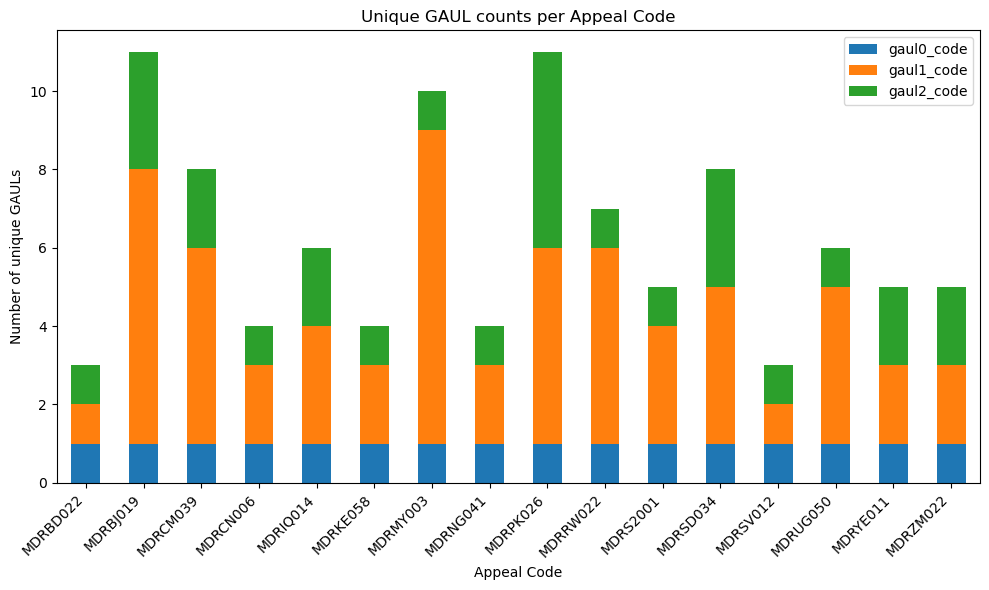

In [31]:
def count_unique_lists(series):
    all_elements = set()
    for lst in series:
        if isinstance(lst, list):
            all_elements.update(lst)
    return len(all_elements)

# Prepare the data
plot_data = df_llm_geo.groupby('appealCode').agg({
    'gaul0_code': count_unique_lists,
    'gaul1_code': count_unique_lists,
    'gaul2_code': count_unique_lists
})

# Plot
ax = plot_data.plot(kind='bar', stacked=True, figsize=(10,6))
ax.set_ylabel("Number of unique GAULs")
ax.set_xlabel("Appeal Code")
ax.set_title("Unique GAUL counts per Appeal Code")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

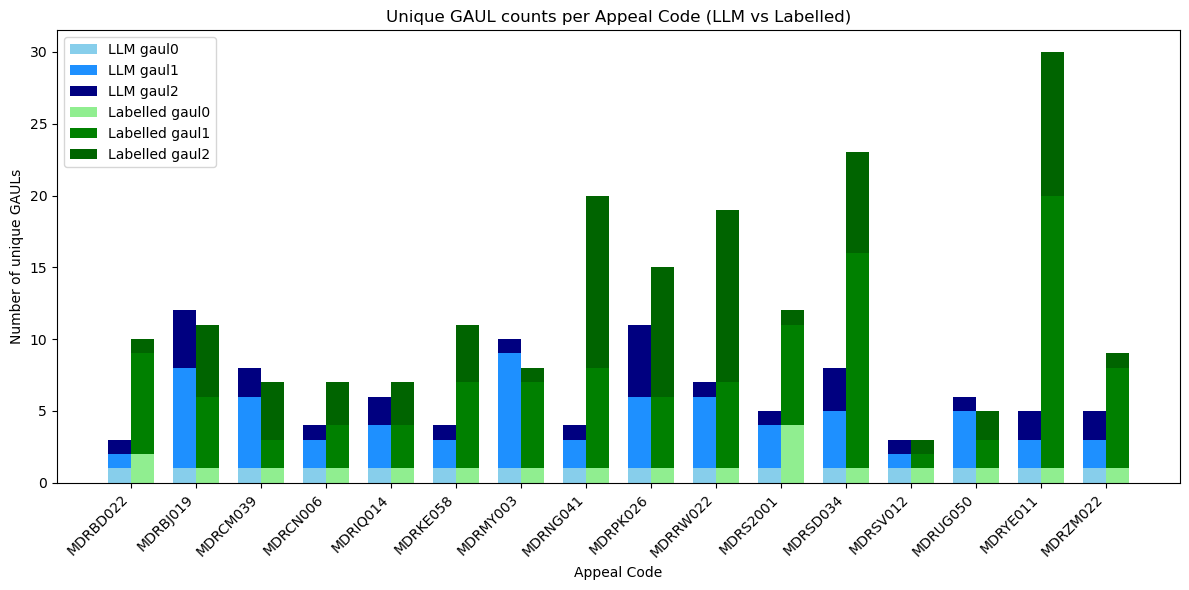

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Function to count unique elements in lists per group
def count_unique_lists(series):
    all_elements = set()
    for lst in series:
        if isinstance(lst, list):
            all_elements.update(lst)
    return len(all_elements)

# Aggregate data for both datasets
plot_data_llm = df_llm_geo.groupby('appealCode').agg({
    'gaul0_code': count_unique_lists,
    'gaul1_code': count_unique_lists,
    'gaul2_code': count_unique_lists
})

plot_data_labelled = df_labelled_geo.groupby('appealCode').agg({
    'gaul0_code': count_unique_lists,
    'gaul1_code': count_unique_lists,
    'gaul2_code': count_unique_lists
})

# Make sure both have the same appealCodes in the same order
all_codes = sorted(set(plot_data_llm.index) | set(plot_data_labelled.index))
plot_data_llm = plot_data_llm.reindex(all_codes, fill_value=0)
plot_data_labelled = plot_data_labelled.reindex(all_codes, fill_value=0)

# Set bar positions
x = np.arange(len(all_codes))
width = 0.35  # width of each bar

# Plot
fig, ax = plt.subplots(figsize=(12,6))

# LLM bars
ax.bar(x - width/2, plot_data_llm['gaul0_code'], width, label='LLM gaul0', color='skyblue', bottom=0)
ax.bar(x - width/2, plot_data_llm['gaul1_code'], width, label='LLM gaul1', color='dodgerblue', bottom=plot_data_llm['gaul0_code'])
bottom_llm = plot_data_llm['gaul0_code'] + plot_data_llm['gaul1_code']
ax.bar(x - width/2, plot_data_llm['gaul2_code'], width, label='LLM gaul2', color='navy', bottom=bottom_llm)

# Labelled bars
ax.bar(x + width/2, plot_data_labelled['gaul0_code'], width, label='Labelled gaul0', color='lightgreen', bottom=0)
ax.bar(x + width/2, plot_data_labelled['gaul1_code'], width, label='Labelled gaul1', color='green', bottom=plot_data_labelled['gaul0_code'])
bottom_labelled = plot_data_labelled['gaul0_code'] + plot_data_labelled['gaul1_code']
ax.bar(x + width/2, plot_data_labelled['gaul2_code'], width, label='Labelled gaul2', color='darkgreen', bottom=bottom_labelled)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(all_codes, rotation=45, ha='right')
ax.set_ylabel("Number of unique GAULs")
ax.set_xlabel("Appeal Code")
ax.set_title("Unique GAUL counts per Appeal Code (LLM vs Labelled)")
ax.legend(loc='upper left')
plt.tight_layout()
fig.savefig(DATA_FIGURE+'counts_unique_loc_admin_appealCode_llm-labelled.png', dpi=300, bbox_inches='tight', transparent=True)

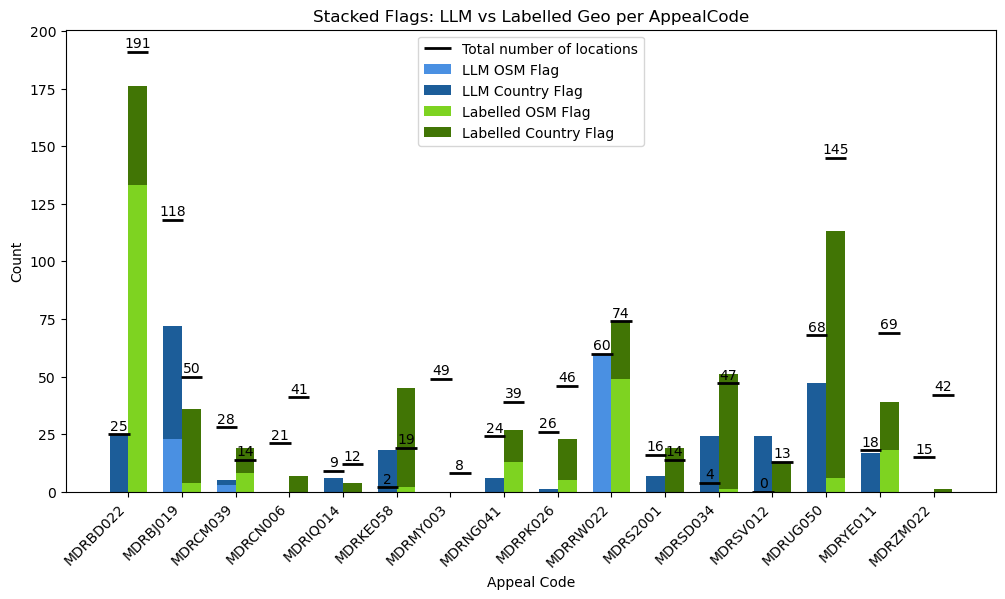

In [84]:
# Compute number of locations per row
for df in [df_llm_geo_split, df_labelled_geo]:
    df['num_locations'] = df['location'].apply(len)

# Group by appealCode
grouped_llm = df_llm_geo_split.groupby('appealCode').agg({
    'num_locations': 'sum',
    'geocoding_osm_flag': 'sum',
    'geocoding_country_flag': 'sum'
}).reset_index()

grouped_labelled = df_labelled_geo.groupby('appealCode').agg({
    'num_locations': 'sum',
    'geocoding_osm_flag': 'sum',
    'geocoding_country_flag': 'sum'
}).reset_index()

# Set bar width and positions
bar_width = 0.35
x = np.arange(len(grouped_llm['appealCode']))

fig, ax = plt.subplots(figsize=(12,6))

# Colors
llm_colors = ['#4A90E2', '#1C5D99']       # Light blue, dark blue
labelled_colors = ['#7ED321', '#417505']  # Light green, dark green

# LLM bars
ax.bar(x - bar_width/2, grouped_llm['geocoding_osm_flag'], bar_width, color=llm_colors[0], label='LLM OSM Flag')
ax.bar(x - bar_width/2, grouped_llm['geocoding_country_flag'], bar_width, 
       bottom=grouped_llm['geocoding_osm_flag'], color=llm_colors[1], label='LLM Country Flag')

# Labelled bars
ax.bar(x + bar_width/2, grouped_labelled['geocoding_osm_flag'], bar_width, color=labelled_colors[0], label='Labelled OSM Flag')
ax.bar(x + bar_width/2, grouped_labelled['geocoding_country_flag'], bar_width, 
       bottom=grouped_labelled['geocoding_osm_flag'], color=labelled_colors[1], label='Labelled Country Flag')

# Plot total reports as lines
for i in range(len(x)):
    ax.hlines(y=grouped_llm['num_locations'][i], xmin=i - bar_width/2 - 0.2, xmax=i - bar_width/2 + 0.2, 
              color='black', lw=2, label='Total number of locations' if i==0 else "")
    ax.text(i - bar_width/2, grouped_llm['num_locations'][i] + 0.5, str(grouped_llm['num_locations'][i]), 
            ha='center', va='bottom', fontsize=10)
    
    ax.hlines(y=grouped_labelled['num_locations'][i], xmin=i + bar_width/2 - 0.2, xmax=i + bar_width/2 + 0.2, 
              color='black', lw=2)
    ax.text(i + bar_width/2, grouped_labelled['num_locations'][i] + 0.5, str(grouped_labelled['num_locations'][i]), 
            ha='center', va='bottom', fontsize=10)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(grouped_llm['appealCode'], rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_xlabel('Appeal Code')
ax.set_title('Stacked Flags: LLM vs Labelled Geo per AppealCode')
ax.legend()
fig.savefig(DATA_FIGURE+'counts_flags_appealCode_llm-labelled.png', dpi=300, bbox_inches='tight', transparent=True)
